In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../공유/final_cleaned_airbnb.csv')

In [4]:
!pip install scipy
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# <0. 통계검정-평점이 높을수록 점유율이 높은가>

### 귀무가설 : 평점과 점유율 사이에 상관관계가 없다.
### 대립가설 : 평점과 점유율 사이에 상관관계가 있다.

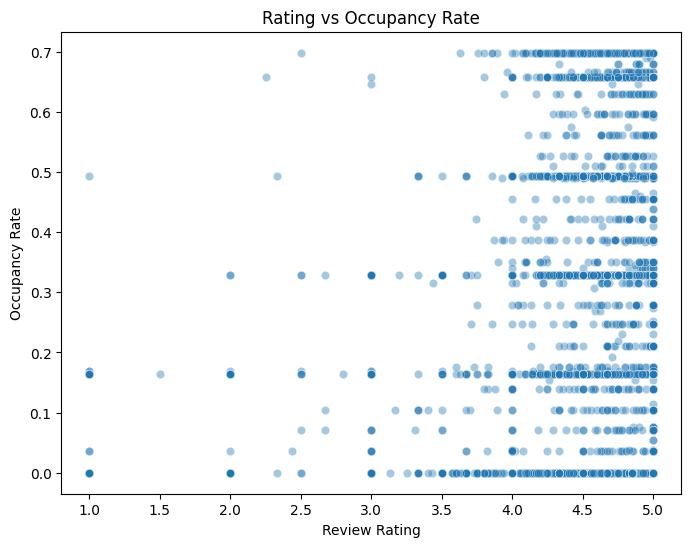

In [5]:
# 평점과 점유율\
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="review_scores_rating",
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.title("Rating vs Occupancy Rate")
plt.xlabel("Review Rating")
plt.ylabel("Occupancy Rate")

plt.show()

- 꼬리가 심하게 오른쪽으로 긴 분포
- 점유율이 특정 값에 집중되어 있어서 연속적인 정규분포가 어난 계단형
- 명확한 선형관계가 아니기 때문에 Spearman이 적절

### Spearman 검정

In [6]:
from scipy.stats import spearmanr

corr, p = spearmanr(df["review_scores_rating"], df["occupancy_rate"])

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.05730715999706616
p-value: 6.351579666086309e-16


### 검정결과
- 상관계수가 0.057고 p-value가 0.05보다 작음
- p < 0.001 => 귀무가설 기각
- 평점과 점유율이 실제로 관계가 없다고 가정했을 때, 이런 상관계수 결과가 우연히 나올 확률이 매우 작다
- p-value가 작은데 왜 영향이 작은 것이냐; 데이터 수가 매우 많으면 작은 차이도 통계적으로 유의하게 나타날 수 있기 때문
- 평점과 점유율은 통계적으로 유의한 관계지만 상관계수 값이 매우 작아서 실제로 영향력은 거의 없다

### 평점과 점유율 사이에 상관관계가 있다.
### 평점과 점유율 사이에는 통계적으로 유의한 상관관계가 존재하지만 값이 0.057로 매우 작기 때문에 실제 영향력은 매우 약한 수준으로 해석

# <1. 통계검정-리뷰수가 많을 수록 점유율이 높은가>

### 귀무가설 : 리뷰 수와 점유율 사이에 상관관계가 없다.
### 대립가설 : 리뷰 수와 점유율 사이에 상관관계가 있다.

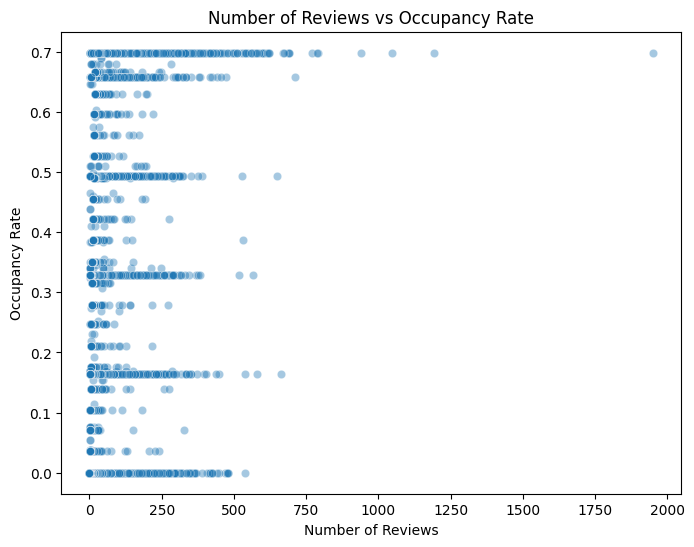

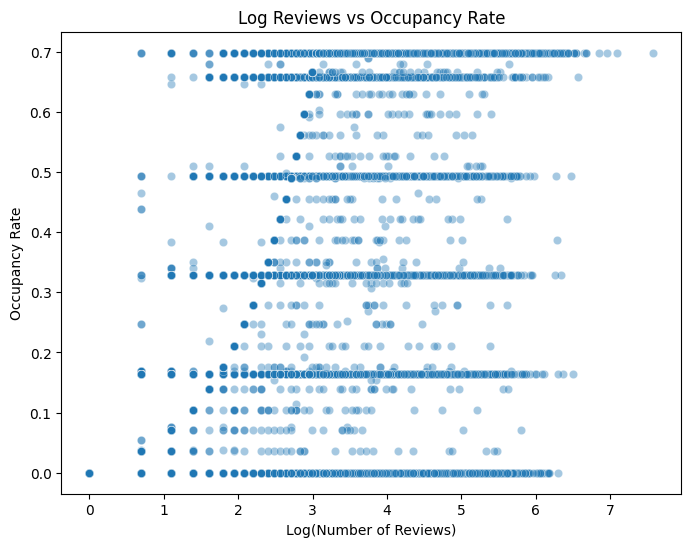

In [7]:
##리뷰수와 점유율
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="number_of_reviews",
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.title("Number of Reviews vs Occupancy Rate")
plt.xlabel("Number of Reviews")
plt.ylabel("Occupancy Rate")

plt.show()

#로그변환
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=np.log1p(df["number_of_reviews"]),
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.xlabel("Log(Number of Reviews)")
plt.ylabel("Occupancy Rate")
plt.title("Log Reviews vs Occupancy Rate")

plt.show()

- number_of_reviews로 산점도 확인해보면 꼬리가 심하게 오른쪽으로 긴 분포를 보였다.
- 그래서 로그로 변환하였고 따라서 비모수 상관계수인 Spearman으로 검정
- 점유율이 특정 값에만 모여있는 연속형이 아닌 계단형 값
- 명확한 선형관계가 아니라서 Spearman이 적절하다고 판다
### Spearman 검정

In [ ]:
from scipy.stats import spearman

rho, p = spearmanr(df["number_of_reviews"], df["occupancy_rate"])

print("Spearman correlation:", rho)
print("p-value:", p)

Spearman correlation: 0.5662275560843235
p-value: 0.0


### 검증결과
 - 상관계수는 ρ = 0.566으로  p-value는 0.001 미만으로 통계적으로 리뷰 수가 많을수록 숙소의 점유율이 유의미한 상관관계 => 귀무가설 기각
 ### 리뷰 수와 점유율 사이에 상관관계가 있다

# <2. 통계검정-리뷰수가 적을수록 매출이 0인 비율이 높은가> 

### 귀무가설 : 리뷰수와 매출 0은 관련이 없다

### 대립가설 :리뷰수와 매출 0은 관련이 있다

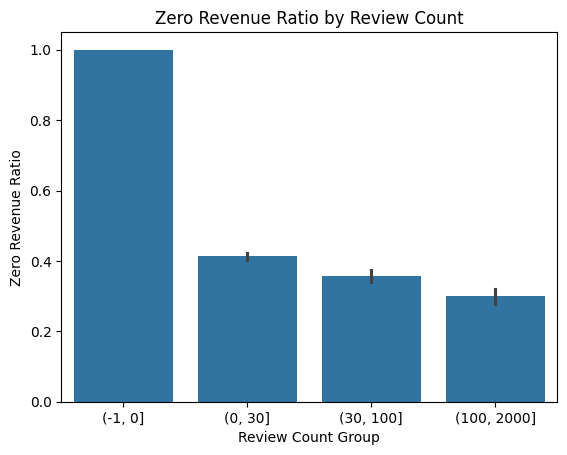

In [9]:
bins = [-1, 0, 30, 100, 2000] # 0이 많아서 경계 겹침, 임의로 구간 나눔-> 0개, 초기, 성장, 인기 숙소

df["review_group"] = pd.cut(df["number_of_reviews"], bins=bins)

df["zero_revenue"] = (df["estimated_revenue_l365d"] == 0).astype(int)

df.groupby("review_group")["zero_revenue"].mean()

sns.barplot(
    x="review_group",
    y="zero_revenue",
    data=df
)

plt.title("Zero Revenue Ratio by Review Count")
plt.ylabel("Zero Revenue Ratio")
plt.xlabel("Review Count Group")

plt.show()

#### 상관관계가 명확히 보이지만 통계적으로 의미 있는 차이인지 판단하기 위해 검정

- 두 변수(리뷰수 구간, 매출발생여부 0/1) 모두 범주형 
- 따라서 카이제곱 검정

### 카이제곱 검정 (범주형 vs 범주형)

In [10]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df["review_group"], df["zero_revenue"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 6910.205537496225
p-value: 0.0


### 검정결과
- 카이제곱 통계량은 6910.21, p-value는 0.001 미만 => 귀무가설 기각
- 시각화 결과에서도 리뷰 수가 증가할수록 매출이 발생하지 않는 숙소의 비율이 감소함을 확인하고 통계적으로 유의한 연관성이 존재함을 확인함

### 리뷰수와 매출 0은 관련이 있다
### 리뷰가 없는 숙소는 시장에서 거의 예약이 발생하지 않는다

# <3. 통계검정-운영기간 길수록 리뷰 많은가> 

### 귀무가설 : 운영기간과 리뷰수는 상관관계가 없다

### 대립가설 :운영기간과 리뷰 수는 상관관계가 있다

6519


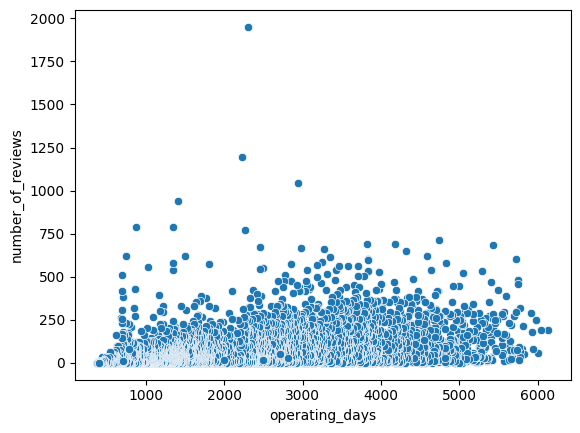

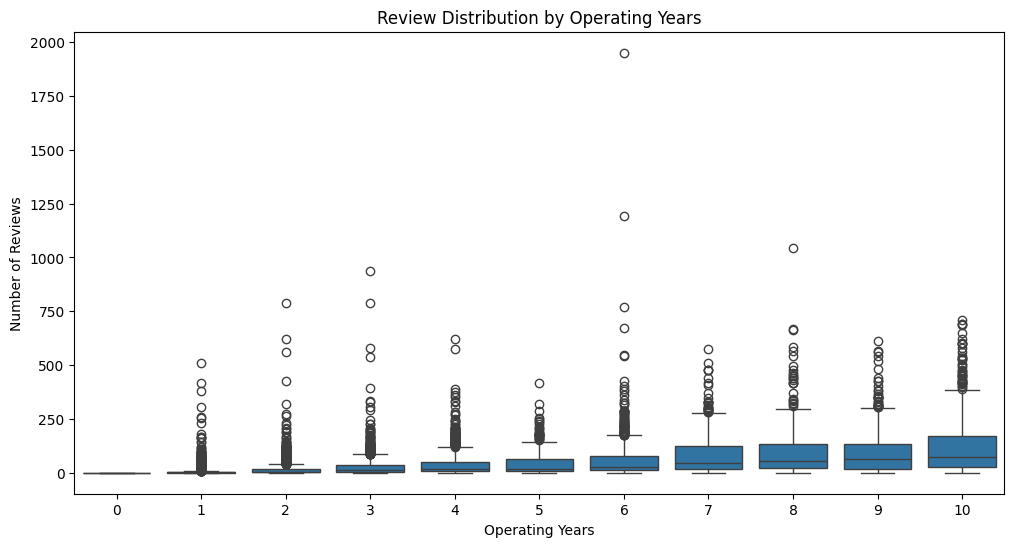

In [11]:
df["first_review"] = pd.to_datetime(df["first_review"])

# 운영 기간 계산
df["operating_days"] = (
    pd.Timestamp("today") - df["first_review"]
).dt.days

sns.scatterplot(
    x="operating_days",
    y="number_of_reviews",
    data=df
)
# 산점도 별로라서 운영 연차별로 묶어서 확인
print(df['operating_days'].isna().sum())
df['operating_years'] = (df['operating_days'] // 365).fillna(0).astype(int)

# 10년 이상은 하나로 
df.loc[df['operating_years'] > 10, 'operating_years'] = 10


plt.figure(figsize=(12, 6))
sns.boxplot(x='operating_years', y='number_of_reviews', data=df)
plt.title("Review Distribution by Operating Years")
plt.xlabel("Operating Years")
plt.ylabel("Number of Reviews")
plt.show()

- operating_years 숫자, 연속형 vs number_of_reviews 숫자, 연속형
- 앞서 봤듯이 리뷰수 데이터 한쪽으로 치우침
- 운영기간 박스플롯 봤을때 선형관계가 아님
- 따라서 Spearman 적절

### Spearman 검정

In [12]:
from scipy.stats import spearmanr

rho, p = spearmanr(df["operating_years"], df["number_of_reviews"])

print("Spearman correlation:", rho)
print("p-value:", p)

Spearman correlation: 0.8705723653743059
p-value: 0.0


### 검정결과
- 상관계수는 ρ = 0.870으로 나타났으며 p-value는 0.001 미만으로 유의미한 통계 => 귀무가설 기각
- 운영기간과 리뷰수 사이에 매우 강한 상관관계가 존재한다
- 즉, 숙소가 오랜 기간 운영될수록 이용 경험이 누적되면서 리뷰 수가 증가하는 경향이 나타났다
### 운영기간과 리뷰 수는 상관관계가 있다

# 리뷰수는 숙소의 점유율과 밀접하게 관련되어 있으며, 리뷰가 많은 숙소일수록 점유율이 높고 매출이 발생할 가능성이 높은 경향을 확인하였다.

In [13]:
revenue_by_district = df.groupby('neighbourhood_group_cleansed')['estimated_revenue_l365d'].sum()

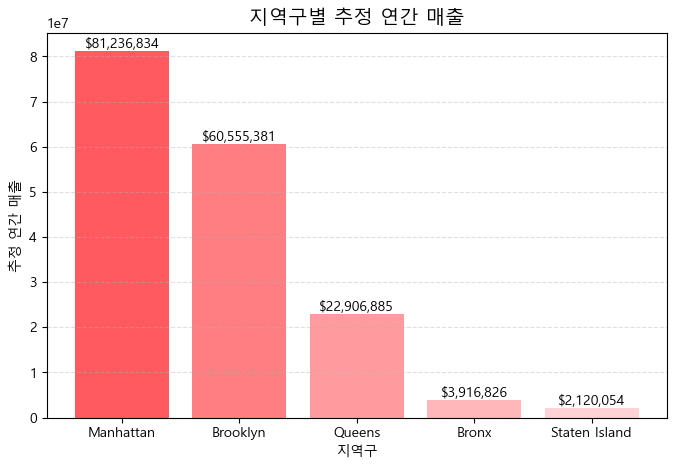

In [19]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

airbnb_palette = ["#FF5A5F", "#FF7E82", "#FF9B9E", "#FFB7BA", "#FFD2D5", "#FFE8EA"]

revenue_by_district = revenue_by_district.sort_values(ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_by_district.index,
    revenue_by_district.values,
    color=airbnb_palette[:len(revenue_by_district)]
)

plt.title("지역구별 추정 연간 매출", fontsize=14)
plt.xlabel("지역구")
plt.ylabel("추정 연간 매출")

plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(revenue_by_district.values):
    plt.text(i, v, f"${v:,.0f}", ha='center', va='bottom')

plt.show()

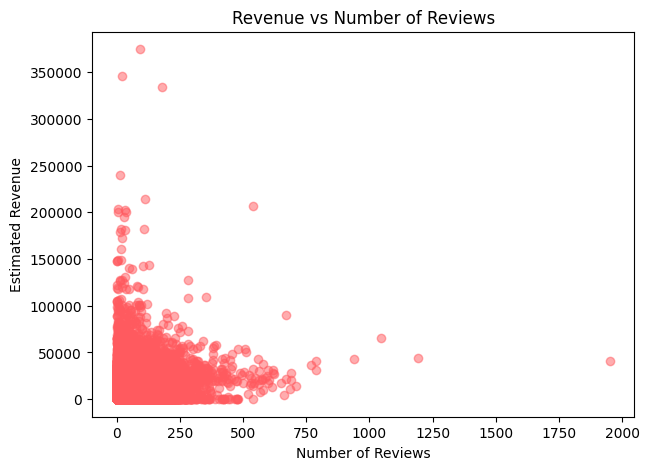

In [15]:
import matplotlib.pyplot as plt

airbnb_coral = "#FF5A5F"

plt.figure(figsize=(7,5))

plt.scatter(
    df['number_of_reviews'],
    df['estimated_revenue_l365d'],
    color=airbnb_coral,
    alpha=0.5
)

plt.title("Revenue vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Estimated Revenue")

plt.show()

C:\Users\yhb05\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yhb05\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yhb05\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yhb05\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yhb05\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46384 (

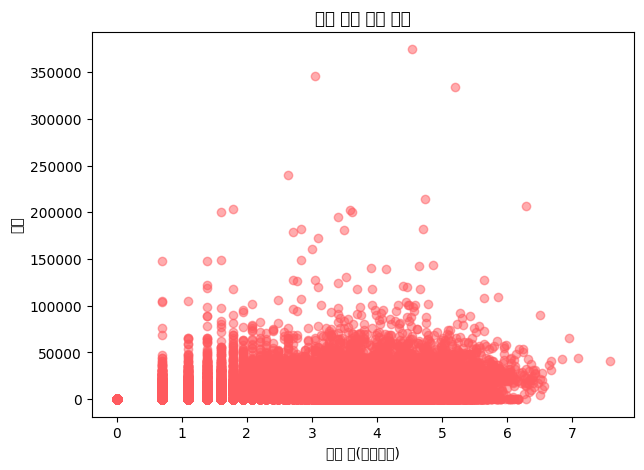

In [16]:
import matplotlib.pyplot as plt

airbnb_coral = "#FF5A5F"

plt.figure(figsize=(7,5))

plt.scatter(
    df['log_reviews'],
    df['estimated_revenue_l365d'],
    color=airbnb_coral,
    alpha=0.5
)

plt.title("리뷰 수에 따른 매출")
plt.xlabel("리뷰 수(로그변환)")
plt.ylabel("매출")

plt.show()

In [17]:
bins = bins = [-1, 0, 10, 50, 100, 500]
labels = ["0", "1-10", "11-50", "51-100" 101-500", "501+"]

df['review_group'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels)

SyntaxError: unterminated string literal (detected at line 2) (3726456413.py, line 2)

In [ ]:
review_revenue = df.groupby('review_group')['estimated_revenue_l365d'].mean()

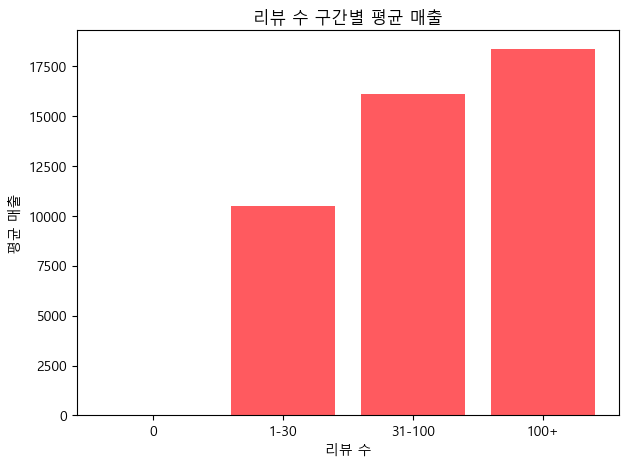

In [ ]:
import matplotlib.pyplot as plt

airbnb_coral = "#FF5A5F"

plt.figure(figsize=(7,5))

plt.bar(
    review_revenue.index,
    review_revenue.values,
    color=airbnb_coral
)

plt.title("리뷰 수 구간별 평균 매출")
plt.xlabel("리뷰 수")
plt.ylabel("평균 매출")

plt.show()

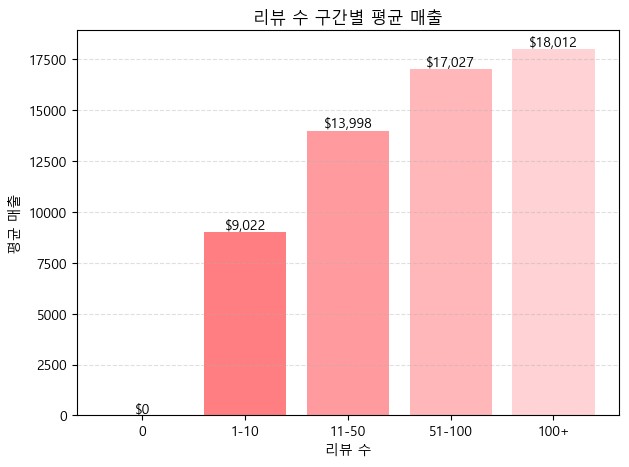

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Airbnb palette
airbnb_palette = ["#FF5A5F", "#FF7E82", "#FF9B9E", "#FFB7BA", "#FFD2D5", "#FFE8EA"]

# 리뷰수 구간 설정
bins = [-1, 0, 10, 50, 100, 500]
labels = ["0", "1-10", "11-50", "51-100", "100+"]

df['review_group'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels)

# 구간별 평균 매출
review_revenue = df.groupby('review_group')['estimated_revenue_l365d'].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(
    review_revenue.index,
    review_revenue.values,
    color=airbnb_palette[:len(review_revenue)]
)

plt.title("리뷰 수 구간별 평균 매출")
plt.xlabel("리뷰 수")
plt.ylabel("평균 매출")

plt.grid(axis='y', linestyle='--', alpha=0.4)

# 막대 위에 $ 매출 표시
for i, v in enumerate(review_revenue.values):
    plt.text(i, v, f"${v:,.0f}", ha='center', va='bottom')

plt.show()


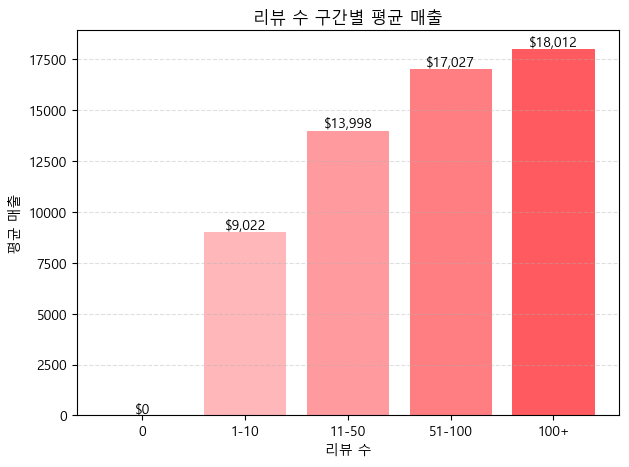

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

airbnb_palette = ["#FF5A5F", "#FF7E82", "#FF9B9E", "#FFB7BA", "#FFD2D5", "#FFE8EA"]

bins = [-1, 0, 10, 50, 100, 500]
labels = ["0", "1-10", "11-50", "51-100", "100+"]

df['review_group'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels)

review_revenue = df.groupby('review_group')['estimated_revenue_l365d'].mean()

colors = airbnb_palette[:len(review_revenue)][::-1]

plt.figure(figsize=(7,5))

bars = plt.bar(
    review_revenue.index,
    review_revenue.values,
    color=colors
)

plt.title("리뷰 수 구간별 평균 매출")
plt.xlabel("리뷰 수")
plt.ylabel("평균 매출")

plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(review_revenue.values):
    plt.text(i, v, f"${v:,.0f}", ha='center', va='bottom')

plt.show()

C:\Users\yhb05\AppData\Local\Temp\ipykernel_46928\2281667188.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='유형', y='경쟁 숙소 수', data=df, palette=colors)


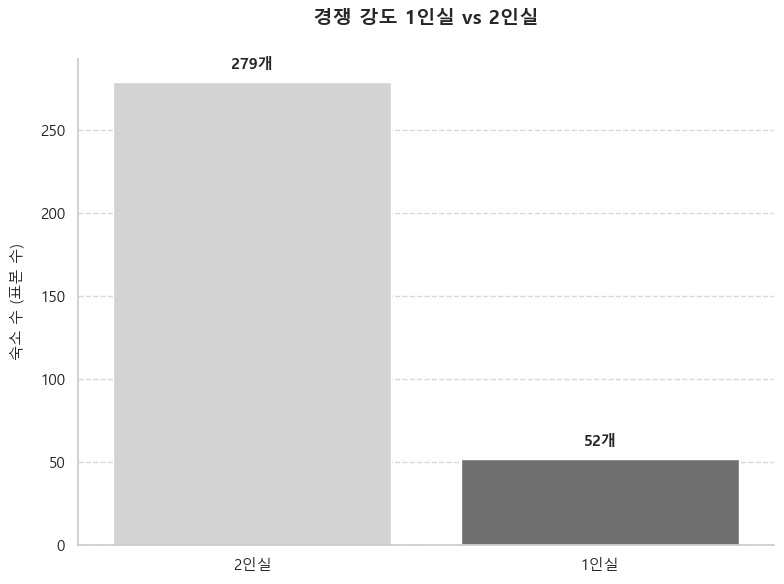

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 데이터 설정
data = {'유형': ['2인실', '1인실'], '경쟁 숙소 수': [279, 52]}
df = pd.DataFrame(data)

# 2. 그래프 스타일 및 폰트 설정
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 회색 계열 컬러 팔레트 (2인실: 연한 회색, 1인실: 짙은 회색으로 강조)
colors = ['#D3D3D3', '#707070'] 

# 3. 바 그래프 그리기
ax = sns.barplot(x='유형', y='경쟁 숙소 수', data=df, palette=colors)

# 제목 및 라벨 설정
plt.title('경쟁 강도 1인실 vs 2인실', fontsize=14, weight='bold', pad=25)
plt.ylabel('숙소 수 (표본 수)', fontsize=11, labelpad=10)
plt.xlabel('', fontsize=11) # X축 라벨은 항목명으로 충분하므로 생략

# 4. 그리드 추가 (가로선 위주로 흐리게 설정)
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True) # 막대가 그리드 위로 오도록 설정

# 5. 수치 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}개', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 12), 
                textcoords='offset points', 
                weight='bold',
                fontsize=11)

# 테두리 정리 (위쪽과 오른쪽 테두리 제거)
sns.despine()

plt.tight_layout()

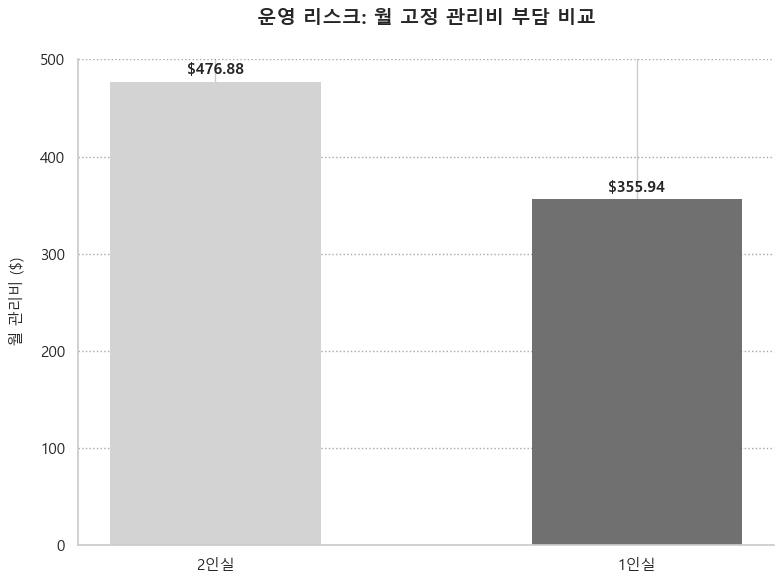

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 설정 (이미지 내 '추정 월 관리비' 수치 활용)
data = {'유형': ['2인실', '1인실'], '월 관리비': [476.88, 355.94]}
df = pd.DataFrame(data)

# 2. 그래프 스타일 및 폰트 설정
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 회색 계열 컬러 (1인실의 낮은 비용을 강조하기 위해 더 짙은 색 사용)
colors = ['#D3D3D3', '#707070'] 

# 3. 바 그래프 그리기
bars = plt.bar(df['유형'], df['월 관리비'], color=colors, width=0.5, edgecolor='none')

# 제목 및 라벨 설정
plt.title('운영 리스크: 월 고정 관리비 부담 비교', fontsize=14, weight='bold', pad=25)
plt.ylabel('월 관리비 ($)', fontsize=11, labelpad=10)

# 4. 그리드 설정 (기존 점선 형태 유지하되 가독성 최적화)
plt.grid(axis='y', linestyle=':', alpha=0.7, color='grey')
plt.gca().set_axisbelow(True) # 막대가 그리드 위로 오도록 설정

# 5. 수치 표시
for i, v in enumerate(df['월 관리비']):
    plt.text(i, v + 8, f'${v:,.2f}', ha='center', weight='bold', fontsize=11)

# 테두리 정리
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
import pandas as pd
import numpy as np
import ast
import warnings
from IPython.display import display

# 설정: 경고 무시 및 소수점 포맷
warnings.filterwarnings('ignore')
pd.set_option("display.float_format", "{:.2f}".format)

# =====================================================
# 1. Data Load & Preprocessing
# =====================================================
# 데이터 경로를 본인의 환경에 맞게 수정하세요.
try:
    df = pd.read_csv("../원본 데이터 셋/2025_Airbnb_NYC_listings.csv")
except FileNotFoundError:
    print("파일 경로를 확인해주세요. 예시용 더미 데이터를 생성하거나 경로 수정을 권장합니다.")

# 가격 클리닝
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
    .astype(float)
)

# Missing Value 처리
df["estimated_occupancy_l365d"] = df["estimated_occupancy_l365d"].fillna(0)
df["occupancy_rate"] = df["estimated_occupancy_l365d"] / 365
df[["bathrooms", "bedrooms", "beds"]] = df[["bathrooms", "bedrooms", "beds"]].fillna(0)

# 규제 및 전략 분류
property_map = {
    "Room in hotel": "Lodging", "Room in boutique hotel": "Lodging",
    "Entire rental unit": "Residential", "Private room in rental unit": "Residential",
    "Private room in home": "Residential", "Entire home": "Residential", "Entire condo": "Residential"
}
df["property_regulation_type"] = df["property_type"].map(property_map).fillna("Other")

def get_strategy(row):
    if row["property_regulation_type"] == "Residential":
        return "Residential_short_term" if row["minimum_nights"] < 30 else "Residential_long_term"
    return "Hotel"

df["rental_strategy"] = df.apply(get_strategy, axis=1)

# 리뷰 수 로그 변환 (참고용)
df["number_of_reviews"] = df["number_of_reviews"].fillna(0)

# =====================================================
# 2. Investment Simulator Function
# =====================================================
def recommend_investor(df, persona, initial_investment, top_n=10):
    # 1. 조건 필터링
    filtered = df[
        (df['rental_strategy'] == persona['rental_strategy']) &
        (df['neighbourhood_group_cleansed'] == persona['neighbourhood_group_cleansed']) &
        (df['room_type'] == persona['room_type'])
    ].copy()

    if filtered.empty:
        return pd.DataFrame()

    # 2. 세그먼트별 성과 지표 계산 (수용 인원별)
    segment_summary = filtered.groupby(['room_type', 'accommodates']).agg(
        median_price=('price', 'median'),
        median_occupancy_rate=('occupancy_rate', 'median'),
        median_revenue=('estimated_revenue_l365d', 'median'),
        listing_count=('price', 'count'),
        median_reviews=('number_of_reviews', 'median')
    ).reset_index()

    # 수익성 지수
    segment_summary['profitability_index'] = (
        segment_summary['median_revenue'] / segment_summary['listing_count']
    )

    # 3. 블루오션/레드오션 판단
    listing_median = segment_summary['listing_count'].median()
    revenue_median = segment_summary['median_revenue'].median()

    def ocean(row):
        if row['listing_count'] < listing_median and row['median_revenue'] >= revenue_median:
            return '블루오션'
        elif row['listing_count'] >= listing_median and row['median_revenue'] >= revenue_median:
            return '레드오션'
        else:
            return '기타'

    segment_summary['시장포지션'] = segment_summary.apply(ocean, axis=1)

    # 4. 수익 계산
    segment_summary['월 매출'] = (
        segment_summary['median_price'] *
        segment_summary['median_occupancy_rate'] * 30
    )
    segment_summary['관리/유지비'] = segment_summary['월 매출'] * 0.25
    segment_summary['월 이익'] = segment_summary['월 매출'] - segment_summary['관리/유지비']

    # 5. 회수기간 계산
    segment_summary['회수기간(월)'] = np.where(
        segment_summary['월 이익'] > 0,
        initial_investment / segment_summary['월 이익'],
        np.nan
    )

    # TOP 추천 (수익순)
    return segment_summary.sort_values(by='월 이익', ascending=False).head(top_n)

# =====================================================
# 3. Execution (Input & Display)
# =====================================================
print("--- 투자자 페르소나 설정 ---")
p_strat = input("운영 전략 (Residential_short_term / Residential_long_term / Hotel): ")
p_room = input("숙소 타입 (Entire home/apt / Private room / Hotel room): ")
p_area = input("지역 (Manhattan / Brooklyn / Queens / Bronx / Staten Island): ")
p_inv = int(input("초기 투자금 ($): "))

persona = {
    'rental_strategy': p_strat,
    'room_type': p_room,
    'neighbourhood_group_cleansed': p_area
}

# 시뮬레이션 실행
result = recommend_investor(df, persona, p_inv)

# 결과 출력
if not result.empty:
    print(f"\n✅ {p_area} 지역 분석 결과입니다.")
    # Jupyter에서 이미지처럼 표로 출력하는 핵심 함수
    display(result) 
else:
    print("\n❌ 조건에 맞는 데이터가 없습니다. 입력값을 확인해주세요.")

--- 투자자 페르소나 설정 ---

✅ Manhattan 지역 분석 결과입니다.


,room_type,accommodates,median_price,median_occupancy_rate,median_revenue,listing_count,median_reviews,profitability_index,시장포지션,월 매출,관리/유지비,월 이익,회수기간(월)
0,Hotel room,1,120.00,0.00,0.00,2,5.50,0.00,블루오션,0.00,0.00,0.00,NaN
1,Hotel room,2,299.00,0.00,0.00,133,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
2,Hotel room,3,1022.00,0.00,0.00,18,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
3,Hotel room,4,372.00,0.00,0.00,65,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
4,Hotel room,5,164.00,0.00,0.00,8,0.00,0.00,블루오션,0.00,0.00,0.00,NaN
5,Hotel room,6,588.00,0.00,0.00,18,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
6,Hotel room,8,521.00,0.00,0.00,46,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
7,Hotel room,9,404.00,0.00,0.00,2,0.00,0.00,블루오션,0.00,0.00,0.00,NaN
8,Hotel room,10,328.00,0.00,0.00,2,0.00,0.00,블루오션,0.00,0.00,0.00,NaN
9,Hotel room,12,790.00,0.00,0.00,35,0.00,0.00,레드오션,0.00,0.00,0.00,NaN
